# Tuning a cavity to a target frequency

The eigenfrequency of an elliptical cell is set by its equator radius `Req`. `cav.tune` adjusts a chosen handle until the fundamental mode lands on a target frequency, re-solving the eigenmode at each step. Here we tune a mid-cell to **1300 MHz**.

See the [tuning guide](../../tuning).

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt

from cavsim2d import EllipticalCavity
from cavsim2d.utils.style import apply_style

apply_style()

## 1. A detuned starting cavity

A TESLA-like cell whose equator radius is deliberately off, so the tuner has something to do.

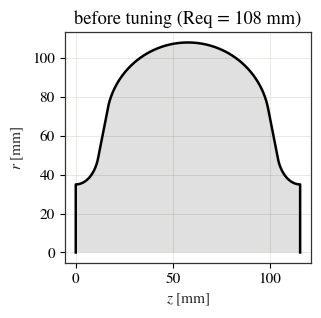

In [2]:
start = [42, 42, 12, 19, 35, 57.7, 108.0]   # Req = 108 mm -> below 1300 MHz
cav = EllipticalCavity(1, start, start, start, beampipe='none', name='tune')
cav.set_workspace(os.path.join(tempfile.mkdtemp(), 'tune'))

ax = cav.plot('geometry')
ax.set_title('before tuning (Req = 108 mm)')
plt.show()

## 2. Tune `Req` to 1300 MHz

`cell_type={'mid-cell': 'Req'}` names the handle; the nested `eigenmode_config` controls the solve used at each tuning step.

In [3]:
cav.tune.run({'freqs': 1300.0,
              'cell_type': {'mid-cell': 'Req'},
              'eigenmode_config': {'boundary_conditions': 'mm',
                                   'mesh_config': {'h': 6, 'p': 2}}})
cav.tune.qois

{'mid-cell': {'parameters': {'A_m': 42.0,
   'B_m': 42.0,
   'a_m': 12.0,
   'b_m': 19.0,
   'Ri_m': 35.0,
   'L_m': 57.7,
   'Req_m': 103.36509503287546},
  'TUNED VARIABLES': ['Req_m'],
  'FREQ': 1300.0000014676984}}

The tuner converges on the equator radius that hits the target:

In [4]:
res = cav.tune.qois['mid-cell']
print(f"reached {res['FREQ']:.3f} MHz at Req = {res['parameters']['Req_m']:.3f} mm")

reached 1300.000 MHz at Req = 103.365 mm


## 3. Convergence history

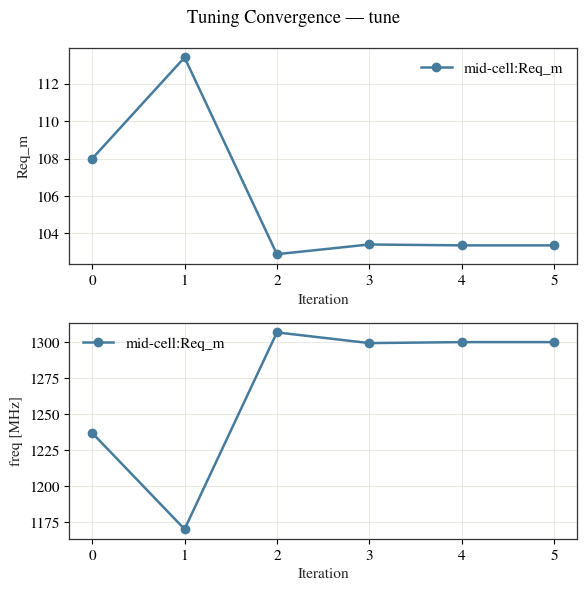

In [5]:
cav.tune.plot_convergence()
plt.show()

## 4. The tuned cavity

`cav.tuned` is a fresh cavity living in `<workspace>/tuned/`; solving its eigenmode confirms it sits on the target frequency.

In [6]:
cav.tuned.eigenmode.run({'polarisation': 'monopole',
                         'boundary_conditions': 'mm',
                         'mesh_config': {'h': 6, 'p': 2}})
print(f"tuned cavity fundamental: {cav.tuned.eigenmode.qois['freq [MHz]']:.3f} MHz")

tuned cavity fundamental: 1236.938 MHz
